# Ampliación de la práctica SAAA Transformer - Óscar Niño Robles

Como se explica en la memoria la idea ha sido escoger otro dataset (con 46 categorías muy desbalanceadas) para que sea una tarea más complicada y para alcanzar ese objetivo mejoraremos los hiperparámetros

## Descarga de las librerías necesarias

In [ ]:
!pip install tensorflow
!pip install keras --upgrade
!pip install livelossplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uni

## Importanciones

Importamos las librerías que usamos en la práctica y además algunas que nos resultarán cómodas (para hacer reporte de clasificación, hacer EarlyStopping y no tener que preocuparnos del número de epochs...)

In [ ]:
import keras
from keras import ops
from keras import layers
from livelossplot import PlotLossesKeras
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

## Transformer block

Igual que en la práctica

In [ ]:
class TransformerBlock(layers.Layer):
    """
    Implementa un bloque Transformer como una capa de Keras.
    Hereda de layers.Layer, podemos usarlo igual que cualquier
    otra capa de Keras: modular y reutilizable.

    Parámetros:
    -----------
    embed_dim : int
        Dimensión del espacio de embedding.

    num_heads : int
        Número de "cabezas" de atención en la Multi-Head Attention.

    ff_dim : int
        Tamaño de la capa oculta en la red Feed-Forward.

    rate : float
        Tasa de Dropout.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        # Llamamos al constructor de la clase padre (layers.Layer)
        # Esto inicializa todas las estructuras internas de Keras
        super().__init__()

        # ─── SUB-CAPA 1: Multi-Head Self-Attention ───────────────────────────
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,   # Número de cabezas de atención en paralelo
            key_dim=embed_dim      # Dimensión de los vectores Query/Key
        )

        # ─── SUB-CAPA 2: Feed-Forward Network (FFN) ──────────────────────────
        # Red completamente conectada que se aplica a CADA POSICIÓN por separado.
        # La primera capa expande la dimensión (captura patrones complejos)
        # La segunda la contrae de vuelta a embed_dim (para mantener consistencia)

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        # ─── CAPAS DE NORMALIZACION ──────────────────────────────────────────────
        # Normaliza las activaciones para estabilizar el entrenamiento.

        self.layernorm1 = layers.LayerNormalization()  # Después de attention
        self.layernorm2 = layers.LayerNormalization()  # Después de FFN

        # ─── DROPOUT ──────────────────────────────────────────────────────────

        self.dropout1 = layers.Dropout(rate)  # Dropout tras la attention
        self.dropout2 = layers.Dropout(rate)  # Dropout tras la FFN

    def call(self, inputs):
        """
        Define el flujo de datos a través del bloque (forward pass).

        inputs: tensor de forma (batch_size, seq_len, embed_dim)
        """
        attn_output = self.att(inputs, inputs)  # Self-attention
        attn_output = self.dropout1(attn_output)

        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)

        return self.layernorm2(out1 + ffn_output)

## Embedding layer

Dos capas de embedding separadas, una para los tokens y otra para los índices de los tokens (posiciones).


In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    """
    Capa de embedding que combina:
    1. Embedding de tokens
    2. Embedding de posición

    Parámetros:
    -----------
    maxlen : int
        Longitud máxima de la secuencia de entrada.

    vocab_size : int
        Tamaño del vocabulario (número de palabras únicas que el modelo conoce).

    embed_dim : int
        Dimensión del vector de embedding.
    """
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()

        # ─── EMBEDDING DE TOKENS ──────────────────────────────────────────────
        # Esta tabla se inicializa aleatoriamente y se APRENDE durante el entrenamiento.
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)

        # ─── EMBEDDING DE POSICIÓN ────────────────────────────────────────────
        # Esta tabla se inicializa aleatoriamente y se APRENDE durante el entrenamiento.
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        """
        Forward pass de la capa de embedding.

        x: tensor de índices de tokens, forma (batch_size, seq_len)
           Cada número es el índice de una palabra en el vocabulario.
           Ej: [1, 14, 3, 22, 0, 0, ...] donde 0 = padding

        Devuelve: tensor de forma (batch_size, seq_len, embed_dim)
        """
        # ops.shape(x)[-1]: cogemos la última dimensión de la forma de x,
        # que es la longitud de la secuencia.
        # Usamos ops.shape (y no x.shape) para que funcione en modo dinámico.
        maxlen = ops.shape(x)[-1]

        # ops.arange genera [0, 1, 2, ..., maxlen-1]
        # Estos índices enteros se pasan al embedding de posición
        positions = ops.arange(start=0, stop=maxlen, step=1)

        # Convertimos cada posición en su vector de embedding
        # Forma de entrada: [0, 1, 2, ..., maxlen-1]
        # Forma de salida: (maxlen, embed_dim)
        positions = self.pos_emb(positions)

        # Para cada índice en x, busca el vector correspondiente en la tabla
        # Forma de x: (batch_size, seq_len)
        # Forma de salida: (batch_size, seq_len, embed_dim)
        x = self.token_emb(x)

        # El broadcasting de numpy/tensorflow se encarga de la suma:
        # x tiene forma (batch_size, maxlen, embed_dim)
        # positions tiene forma (maxlen, embed_dim)
        # → Se suma la misma posición para todas las muestras del batch
        return x + positions

## Dataset

Vamos a cambiar el dataset para complicar más la tarea, usaremos el dataset `reuters` que también está incorporado en Keras. Se puede encontrar más información [aquí](https://https://keras.io/api/datasets/reuters/). El dataset es un dataset de noticias con 46 categorías para clasificarlas.

Como ahora nos enfrentamos a una tarea más complicada que en la práctica, aumentamos el número máximo de palabras a 400 (ya que las noticias son más largas).

In [ ]:
vocab_size = 20000  # Solo consideramos las 20k palabras más frecuentes
maxlen = 400  # Solo consideramos las primeras 400 palabras de cada noticia
(x_train, y_train), (x_val, y_val) = keras.datasets.reuters.load_data(num_words=vocab_size)
print(len(x_train), "Training sequences")
print(len(x_val), "Validation sequences")

# pad_sequences TRUNCA las secuencias más largas que maxlen (se queda con las últimas
# 200 palabras) y RELLENA con 0s al PRINCIPIO (por defecto) las secuencias más cortas

x_train = keras.utils.pad_sequences(x_train, maxlen=maxlen)
x_val = keras.utils.pad_sequences(x_val, maxlen=maxlen)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
8982 Training sequences
2246 Validation sequences


In [ ]:
# Índices especiales de los datasets de Keras (como Reuters o IMDB):
start_char = 1   # Token que marca el inicio de la secuencia
oov_char   = 2   # Token para palabras desconocidas (Out Of Vocabulary)
index_from = 3   # Las palabras reales empiezan desde el índice 3

# Devuelve el archivo de los indices de las palabras, que asocia las palabras
# con los índices
word_index = keras.datasets.reuters.get_word_index()

# Invertimos el diccionario: índice → palabra
# Sumamos index_from para sincronizar con los índices de x_train
# (Keras añade un offset de 3 para reservar 0=padding, 1=start, 2=OOV)
inverted_word_index = dict(
    (i + index_from, word) for (word, i) in word_index.items()
)

# Actualizamos `inverted_word_index` para incluir `start_char` y `oov_char`
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"

# Decodificamos la primera secuencia del dataset
# Si no encuentra el índice (como el 0), pondrá "[PAD]" automáticamente
decoded_sequence = " ".join(inverted_word_index.get(i, "[PAD]") for i in x_train[0])
print(decoded_sequence)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

In [ ]:
decoded_sequence

'[PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PA

In [ ]:
y_train[0]

np.int64(3)

Vemos ahora el balanceo de clases (que, **Spoiler**: Es horrible).

TOTAL DE CLASES ENCONTRADAS: 46
TOP 5 Clases MÁS frecuentes :
 - Clase  3: 3159 noticias (35.2%)
 - Clase  4: 1949 noticias (21.7%)
 - Clase 19:  549 noticias (6.1%)
 - Clase 16:  444 noticias (4.9%)
 - Clase  1:  432 noticias (4.8%)

TOP 5 Clases MENOS frecuentes :
 - Clase 27:   15 noticias (0.167%)
 - Clase 42:   13 noticias (0.145%)
 - Clase 44:   12 noticias (0.134%)
 - Clase 33:   11 noticias (0.122%)
 - Clase 35:   10 noticias (0.111%)


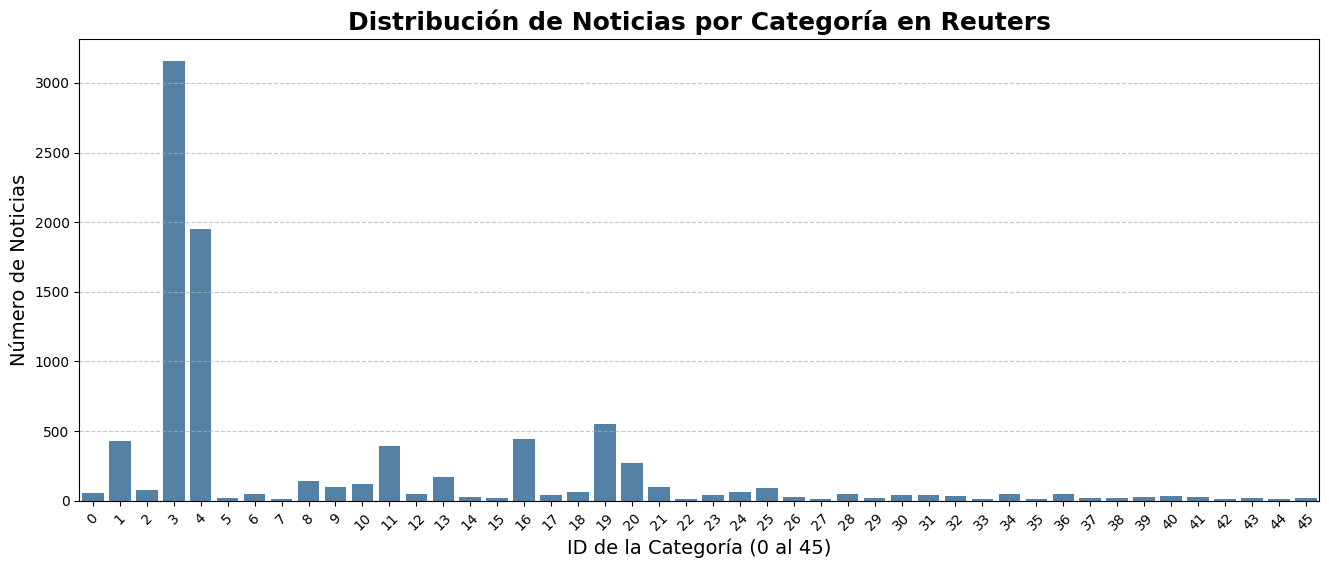

In [ ]:
# Contamos cuántas veces aparece cada clase en el set de entrenamiento
clases, frecuencias = np.unique(y_train, return_counts=True)

# --- SALIDA POR TEXTO RÁPIDA ---
print("=" * 40)
print(f"TOTAL DE CLASES ENCONTRADAS: {len(clases)}")
print("=" * 40)

# Unimos las clases con sus frecuencias y las ordenamos de mayor a menor
distribucion = list(zip(clases, frecuencias))
distribucion.sort(key=lambda x: x[1], reverse=True)

print("TOP 5 Clases MÁS frecuentes :")
for c, f in distribucion[:5]:
    # Calculamos también el porcentaje que representan
    porcentaje = (f / len(y_train)) * 100
    print(f" - Clase {c:2d}: {f:4d} noticias ({porcentaje:.1f}%)")

print("\nTOP 5 Clases MENOS frecuentes :")
for c, f in distribucion[-5:]:
    porcentaje = (f / len(y_train)) * 100
    print(f" - Clase {c:2d}: {f:4d} noticias ({porcentaje:.3f}%)")


# --- GRÁFICA VISUAL  ---
plt.figure(figsize=(16, 6))

# Pintamos el gráfico de barras ordenado por ID de clase
sns.barplot(x=clases, y=frecuencias, color="steelblue")

plt.title("Distribución de Noticias por Categoría en Reuters", fontsize=18, fontweight='bold')
plt.xlabel("ID de la Categoría (0 al 45)", fontsize=14)
plt.ylabel("Número de Noticias", fontsize=14)

# Ponemos una cuadrícula horizontal para que sea más fácil leer las alturas
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Rotamos las etiquetas del eje X por si se aprietan los números
plt.xticks(rotation=45)


plt.show()

Vemos que las clases están horriblemente balanceadas, tendremos que tener esto en cuenta para nuestro entrenamiento.

## Preparación del modelo

Vamos a mejorar un poco los parámetros pues esta tarea es más difícil, haciendo `embed_dim = 64` (en lugar de 32), `num_heads=4` (en lugar de 2) y `ff_dim = 128` (en lugar de 32). También tendremos que ajustar el número de clases respecto al modelo de la gráfica.

Por otro lado, no solo mejoramos los parámetros si no que también vamos a apilar dos **transformer blocks** para aumentar la abstracción ya que así se buscan patrones mucho más complejos, consiguiendo así un mejor aprendizaje. Esto lo hacemos debido a que la tarea es más compleja que la de la práctica (decir si las reseñas son positivas o negativas).

No añadimos más bloques pues la tarea no es TAN complicada, veremos luego que con dos tenemos bastante. Además de que a más bloques tendremos más coste computacional y aumento del sobreajuste.

In [ ]:
embed_dim = 64  #Tamaño del embedding para cada token
num_heads = 4  # Numero de attention heads
ff_dim = 128  # Tamaño de la capa oculta en la red feed-forward dentro del transformer
num_classes = 46

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)


transformer_block_1 = TransformerBlock(embed_dim, num_heads, ff_dim,rate=0.3)
x = transformer_block_1(x)

transformer_block_2 = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.3)
x = transformer_block_2(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

También metemos más dropout para regularizar y que la red no memorice en exceso, ayudando a evitar el sobreajuste. También hemos hecho más ancha una capa densa respecto a la práctica (pasandola de 20 neuronas a 64) para evitar un cuello de botella (si condesaramos la información en 20 neuronas como en la práctica tendríamos problemas luego al tener 46 clases).

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 400, 64)        │     1,305,600 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 400, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 400, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,479,150 (5.64 MB)

 Trainable params: 1,479,150 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

En el resumen del modelo vemos que tenemos aproximadamente millón y medio de parámetros.

## Entrenamiento y evaluación

Como novedad, al estar las clases tan desbalanceadas entrenaremos buscando aumentar el **f1 score** en lugar del *accuracy*. Esto se debe a que aumentando el accuracy el modelo solo quiere acertar muchas (se va a centrar solo en las clases mayoritarias y va a ignorar las minoritarias), como el f1 score compensa este desbalanceo de clases, el modelo va a intentar aprender de todas las clases por igual.

Para ayudar a este cometido, usaremos **focal loss**, que sirve para ajustar la Entropía Categórica  de forma que fuerza a la red neuronal a ignorar absolutamente los ejemplos que ya se sabe de memoria (las clases mayoritarias) y a concentrar todo el ajuste de pesos en los ejemplos que le están costando (las clases raras).

También usaremos `Early Stopping` que lo que hace es cortar el entrenamiento cuando deja de mejorar, así no nos tenemos que preocupar del número de epochs (ponemos un número grande y ya se cortará solo).

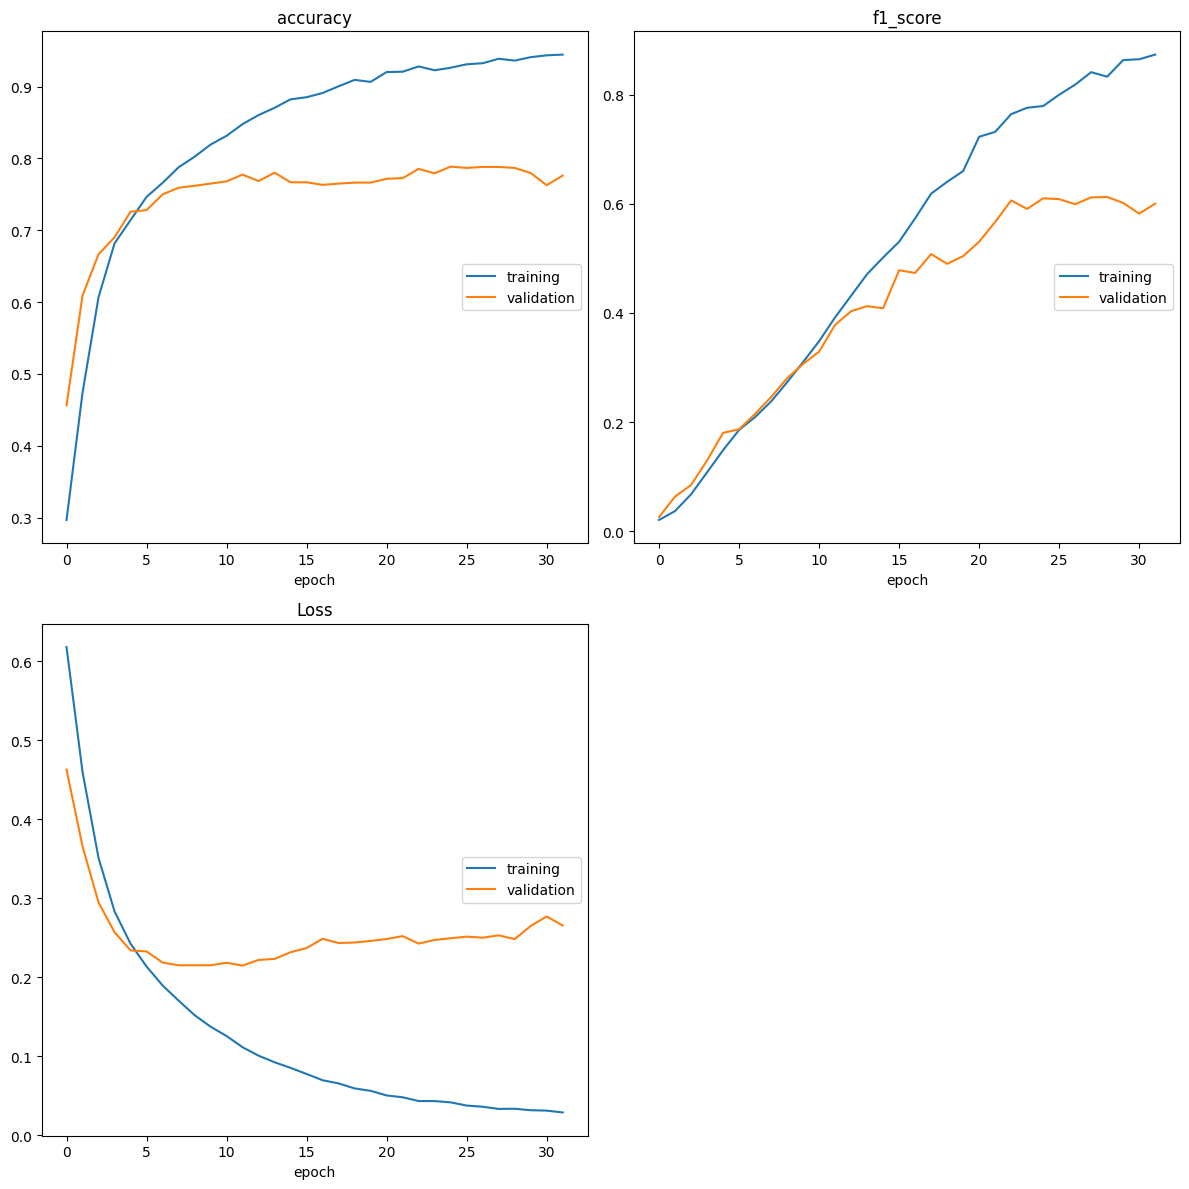

accuracy
	training         	 (min:    0.297, max:    0.944, cur:    0.944)
	validation       	 (min:    0.456, max:    0.789, cur:    0.776)
f1_score
	training         	 (min:    0.021, max:    0.874, cur:    0.874)
	validation       	 (min:    0.026, max:    0.613, cur:    0.600)
Loss
	training         	 (min:    0.029, max:    0.618, cur:    0.029)
	validation       	 (min:    0.215, max:    0.463, cur:    0.266)
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9444 - f1_score: 0.8735 - loss: 0.0288 - val_accuracy: 0.7760 - val_f1_score: 0.6004 - val_loss: 0.2655


In [ ]:
# --- CONVERTIMOS ETIQUETAS A ONE-HOT ENCODING ---
# Keras necesita esto para calcular bien el F1-Score y el Focal Loss
y_train_oh = keras.utils.to_categorical(y_train, num_classes=46)
y_val_oh = keras.utils.to_categorical(y_val, num_classes=46)

# --- COMPILAMOS CON FOCAL LOSS Y F1-SCORE ---
# Como ahora usamos One-Hot, quitamos lo de "sparse" de la función de pérdida
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),

    # Focal Loss: gamma=2.0 obliga al modelo a centrarse en los errores difíciles
    loss=keras.losses.CategoricalFocalCrossentropy(gamma=2.0),

    # Le pedimos que calcule el F1-Score haciendo la media de las 46 clases (macro)
    metrics=['accuracy', keras.metrics.F1Score(average='macro', name='f1_score')]
)

# --- ENTRENAMOS  ---
# Le decimos al EarlyStopping que vigile el F1-Score y que se quede
# con el máximo
parada_temprana = EarlyStopping(
    monitor='val_f1_score',
    patience=3,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train_oh,
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val_oh),
    callbacks=[PlotLossesKeras(), parada_temprana]
)

Ahora llega el momento de estudiar el modelo, viendo cómo de bien funciona. Para ello calculamos el `Clasification Report`.

In [ ]:
# Sacamos las predicciones del modelo (nos da un array de probabilidades)
y_pred_probabilidades = model.predict(x_val)

# Pasamos las probabilidades y el One-Hot a números enteros (0 al 45)
# np.argmax coge el índice de la probabilidad más alta
y_pred = np.argmax(y_pred_probabilidades, axis=1)
y_true = np.argmax(y_val_oh, axis=1) # Usamos y_val_oh que creamos antes

# --- REPORTE DE CLASIFICACIÓN ---
print("="*50)
print("REPORTE DE CLASIFICACIÓN")
print("="*50)
print(classification_report(y_true, y_pred))


71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.74      0.80      0.77       105
           2       0.67      0.60      0.63        20
           3       0.91      0.91      0.91       813
           4       0.82      0.85      0.83       474
           5       0.00      0.00      0.00         5
           6       0.87      0.93      0.90        14
           7       1.00      0.33      0.50         3
           8       0.57      0.63      0.60        38
           9       0.76      0.88      0.81        25
          10       0.90      0.90      0.90        30
          11       0.64      0.67      0.66        83
          12       0.38      0.38      0.38        13
          13       0.51      0.51      0.51        37
          14       0.50      1.00      0.67         2
          15       0.67      0.22      0.33         9
          16    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Vemos que en general el modelo funciona bastante bien, tiene un *accuracy* alto, además de un f1 score ponderado (el que pone *weighted avg*) también elevado. El f1 score en media sin ponderar (el que pone *macro avg*) también está bastante bien contando con las clases tan minoritarias y desbalanceadas que tenemos. La diferencia entre el f1 score medio crudo y el ponderado es que el ponderado le da más peso a las clases mayoritarias, y el crudo es la media tal cual (le da la misma importancia a todas las clases).

Podemos afirmar entonces que nuestro modelo ha aprendido, pero realicemos el siguiente experimento para ir más allá. Tomaremos nuestro mismo modelo (no entrenaremos otro) y quitaremos todas las clases que suponen menos de un 2%. Elegimos este umbral porque como tenemos 46 clases, si estuvieran balanceadas se esperaría en media un 2% de cada clase.

Con este umbral y nuestro mismo modelo veamos el reporte de clasificación de lo que serian las clases mayoritarias a ver cómo de bueno es.

Conviene recordar que usaremos el modelo **entrenado para todas las clases**, que se ha construido penalizando además los errores en las clases minoritarias para obtener un buen f1 score. Si se entrenase otro modelo sólo con estas clases mayoritarias sería mucho mejor.

In [ ]:
# Contamos el total de noticias en el set de validación
total_noticias = len(y_true)

# Contamos cuántas hay de cada clase
clases, frecuencias = np.unique(y_true, return_counts=True)

# Creamos una lista para guardar SOLO las clases "grandes"
umbral_porcentaje = 2.0 # El 2% que hemos dicho
clases_frecuentes = []

print("=" * 50)
print(f"FILTRANDO CLASES (Umbral >= {umbral_porcentaje}%)")
print("=" * 50)

for c, f in zip(clases, frecuencias):
    porcentaje = (f / total_noticias) * 100
    if porcentaje >= umbral_porcentaje:
        clases_frecuentes.append(c)
        print(f" - Clase {c:2d} INCLUIDA: {porcentaje:.2f}% ({f} noticias)")

print("-" * 50)
print(f"Total de clases que superan el filtro: {len(clases_frecuentes)} de {len(clases)}")
print("-" * 50)

# Le pasamos la lista al parámetro 'labels'
print("\nREPORTE DE CLASIFICACIÓN (Solo clases principales):")
print(classification_report(y_true, y_pred, labels=clases_frecuentes))

FILTRANDO CLASES (Umbral >= 2.0%)
 - Clase  1 INCLUIDA: 4.67% (105 noticias)
 - Clase  3 INCLUIDA: 36.20% (813 noticias)
 - Clase  4 INCLUIDA: 21.10% (474 noticias)
 - Clase 11 INCLUIDA: 3.70% (83 noticias)
 - Clase 16 INCLUIDA: 4.41% (99 noticias)
 - Clase 19 INCLUIDA: 5.92% (133 noticias)
 - Clase 20 INCLUIDA: 3.12% (70 noticias)
--------------------------------------------------
Total de clases que superan el filtro: 7 de 46
--------------------------------------------------

REPORTE DE CLASIFICACIÓN (Solo clases principales):
              precision    recall  f1-score   support

           1       0.74      0.80      0.77       105
           3       0.91      0.91      0.91       813
           4       0.82      0.85      0.83       474
          11       0.64      0.67      0.66        83
          16       0.72      0.72      0.72        99
          19       0.65      0.69      0.67       133
          20       0.54      0.53      0.53        70

   micro avg       0.82      0

## Final alternativo: Otro modelo

Siguiendo el hilo del apartado anterior, vamos a entrenar otro modelo. Este funcionará de la siguiente forma, las clases que tengan una representación mayor al 2% seguirán tal y como están, en cambio todas las clases que tengan una representación menor al 2% se agruparán como una sola. La primera idea podría ser eliminar todas las clases minoritarias, pero como el modelo está obligado a asignar probabilidades que sumen 100%, el modelo estaría clasificando todas las observaciones provenientes de clases minoritarias como incorrectas simplemente por fuerza bruta.

In [ ]:
# Contamos frecuencias en el set de entrenamiento original
total_noticias = len(y_train)
clases, frecuencias = np.unique(y_train, return_counts=True)

# Separamos las clases que superan el 2% de representación
umbral = 0.02 * total_noticias
clases_principales = [c for c, f in zip(clases, frecuencias) if f >= umbral]

# Creamos un diccionario para remapear las clases (0, 1, 2... N)
mapeo_clases = {}
nueva_id = 0

for c in clases_principales:
    mapeo_clases[c] = nueva_id
    nueva_id += 1

id_otros = nueva_id # La categoría "Otros" será el último número

# Asignamos la categoría "Otros" a todas las clases minoritarias
for c in clases:
    if c not in clases_principales:
        mapeo_clases[c] = id_otros

# Aplicamos el mapeo a nuestros datasets originales
y_train_agrupado = np.array([mapeo_clases[y] for y in y_train])

y_val_agrupado = np.array([mapeo_clases[y] for y in y_val])

num_classes_nuevo = id_otros + 1

print(f"Clases originales: 46")
print(f"Clases nuevas: {num_classes_nuevo} ({num_classes_nuevo - 1} temáticas principales + 1 saco de 'Otros')")

Clases originales: 46
Clases nuevas: 8 (7 temáticas principales + 1 saco de 'Otros')


Vemos el balanceo ahora

NUEVA DISTRIBUCIÓN DE CLASES (Total: 8)
 - Clase  1 original   :  432 noticias (4.8%)
 - Clase  3 original   : 3159 noticias (35.2%)
 - Clase  4 original   : 1949 noticias (21.7%)
 - Clase 11 original   :  390 noticias (4.3%)
 - Clase 16 original   :  444 noticias (4.9%)
 - Clase 19 original   :  549 noticias (6.1%)
 - Clase 20 original   :  269 noticias (3.0%)
 - Otros (Minorías)    : 1790 noticias (19.9%)


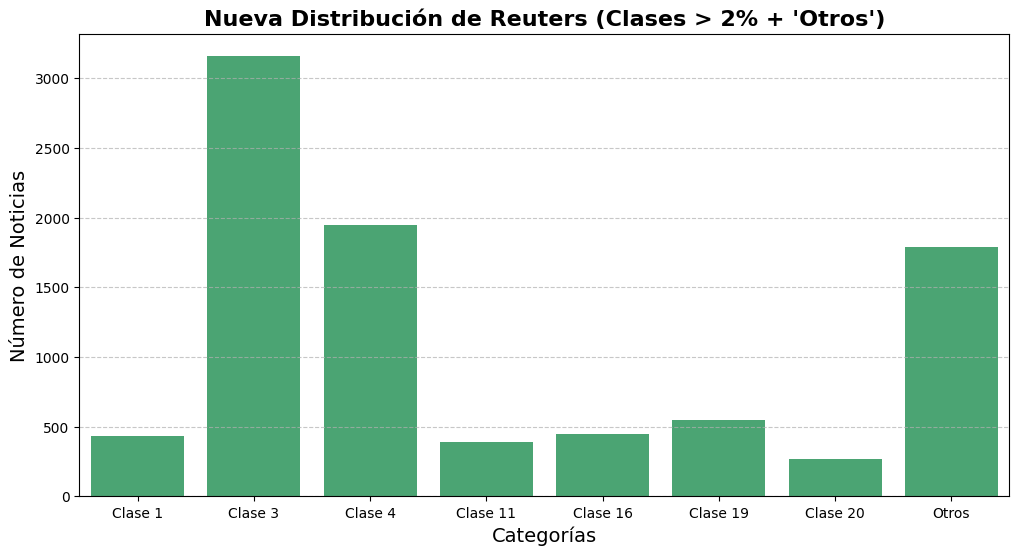

In [ ]:
# Contamos las frecuencias del NUEVO dataset agrupado
clases_nuevas, frecuencias_nuevas = np.unique(y_train_agrupado, return_counts=True)

# --- SALIDA POR TEXTO ---
print("=" * 50)
print(f"NUEVA DISTRIBUCIÓN DE CLASES (Total: {len(clases_nuevas)})")
print("=" * 50)

# Imprimimos el recuento, marcando cuál es la categoría "Otros"
for c, f in zip(clases_nuevas, frecuencias_nuevas):
    porcentaje = (f / len(y_train_agrupado)) * 100

    # Si es el último ID, sabemos que es nuestro saco de "Otros"
    if c == id_otros:
        nombre_clase = "Otros (Minorías)"
    else:
        # Recuperamos el ID original para que sepamos qué clase es
        id_original = clases_principales[c]
        nombre_clase = f"Clase {id_original:2d} original"

    print(f" - {nombre_clase:<20}: {f:4d} noticias ({porcentaje:.1f}%)")

# --- GRÁFICA VISUAL  ---
plt.figure(figsize=(12, 6))

# Nombres personalizados para el eje X
nombres_x = [f"Clase {clases_principales[c]}" if c != id_otros else "Otros" for c in clases_nuevas]

# Pintamos la gráfica
sns.barplot(x=nombres_x, y=frecuencias_nuevas, color="mediumseagreen")

plt.title("Nueva Distribución de Reuters (Clases > 2% + 'Otros')", fontsize=16, fontweight='bold')
plt.xlabel("Categorías", fontsize=14)
plt.ylabel("Número de Noticias", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Evidentemente las clases siguen desbalanceadas, pero no todos los datasets pueden ser perfectos. Este balanceo es mas "sano" que el anterior

Ya con los datos pasamos al entrenamiento del modelo, podemos bajar un poco el dropout y quitar la focal loss pues ya no tenemos tanto problemas al haber quitado muchas clases ruidosas. También nos podemos permitir entrenar siguiendo el *accuracy* que es computacionalmente mucho menos costoso.

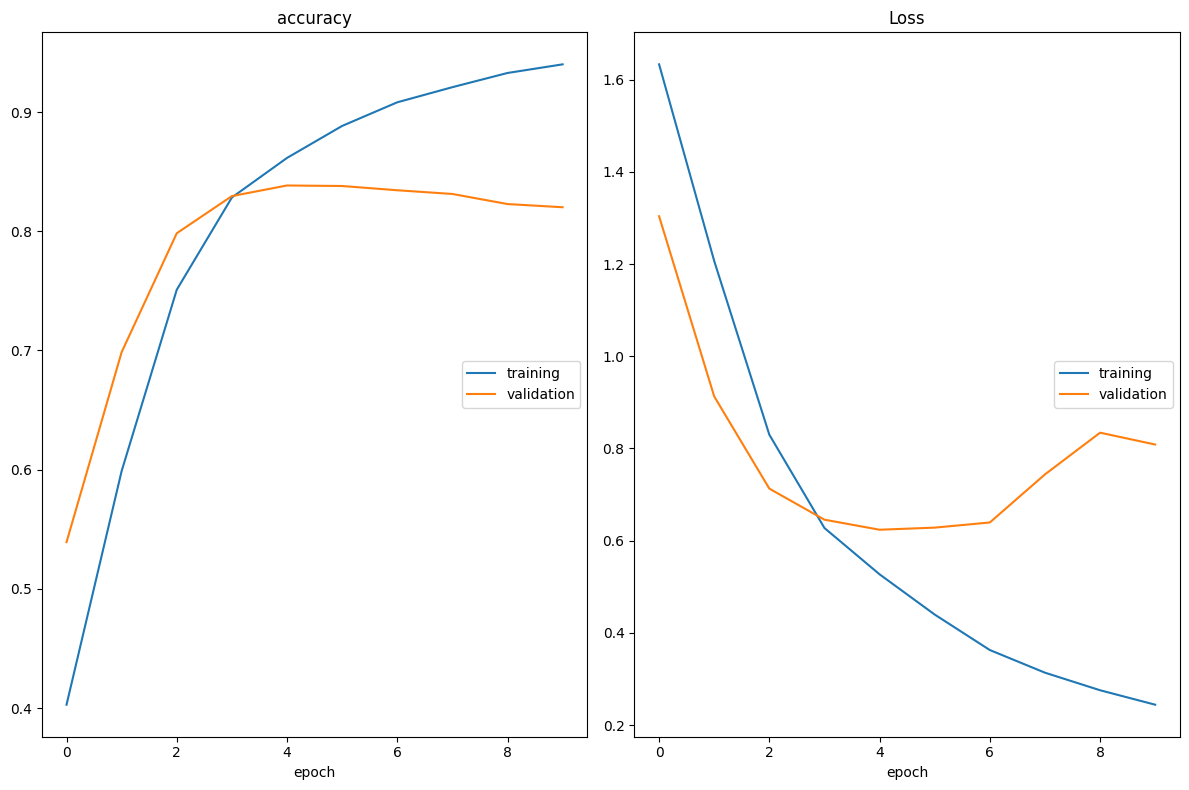

accuracy
	training         	 (min:    0.403, max:    0.940, cur:    0.940)
	validation       	 (min:    0.539, max:    0.838, cur:    0.820)
Loss
	training         	 (min:    0.244, max:    1.633, cur:    0.244)
	validation       	 (min:    0.624, max:    1.304, cur:    0.809)
281/281 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9400 - loss: 0.2444 - val_accuracy: 0.8201 - val_loss: 0.8086


In [ ]:
# --- NUEVA ARQUITECTURA ---
inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)

transformer_block_1 = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.25)
x = transformer_block_1(x)

transformer_block_2 = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.25)
x = transformer_block_2(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.25)(x)

# CRÍTICO: Usamos el nuevo número de clases en la capa de salida
outputs = layers.Dense(num_classes_nuevo, activation="softmax")(x)

modelo_2 = keras.Model(inputs=inputs, outputs=outputs)

# --- COMPILACIÓN SIMPLE ---
# Volvemos a sparse_categorical_crossentropy porque el desbalanceo extremo ya no existe
modelo_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- ENTRENAMIENTO ---
# Paramos si el accuracy de validación no mejora en 5 épocas
parada_temprana = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = modelo_2.fit(
    x_train, y_train_agrupado,     # Le pasamos nuestras nuevas etiquetas limpias
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val_agrupado),
    callbacks=[PlotLossesKeras(), parada_temprana]
)

Sacamos el reporte de clasificación de este modelo

In [ ]:
# Sacamos las predicciones de nuestro nuevo modelo
y_pred_probabilidades = modelo_2.predict(x_val)

# Nos quedamos con la clase ganadora (índices 0, 1, 2... hasta el id_otros)
y_pred = np.argmax(y_pred_probabilidades, axis=1)

# Las etiquetas reales ya las tenemos preparadas del paso anterior
y_true = y_val_agrupado

# --- PREPARAMOS LOS NOMBRES  ---
# Usamos las clases principales que calculamos antes y le añadimos "Otros" al final
nombres_clases = [f"Clase {c}" for c in clases_principales]
nombres_clases.append("Otros")

# --- REPORTE DE CLASIFICACIÓN ---
print("="*55)
print("REPORTE DE CLASIFICACIÓN (Modelo Élite Agrupado)")
print("="*55)
# Pasamos 'target_names' para que imprima los nombres reales
print(classification_report(y_true, y_pred, target_names=nombres_clases))

71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
REPORTE DE CLASIFICACIÓN (Modelo Élite Agrupado)
              precision    recall  f1-score   support

     Clase 1       0.83      0.80      0.82       105
     Clase 3       0.90      0.95      0.93       813
     Clase 4       0.88      0.82      0.85       474
    Clase 11       0.76      0.60      0.67        83
    Clase 16       0.77      0.73      0.75        99
    Clase 19       0.69      0.66      0.68       133
    Clase 20       0.84      0.37      0.51        70
       Otros       0.76      0.86      0.81       469

    accuracy                           0.84      2246
   macro avg       0.80      0.72      0.75      2246
weighted avg       0.84      0.84      0.83      2246



Comparando los dos, tenemos que este es algo mejor que el otro. Esto desde luego, ya se esperaba. Si quisieramos intentar mejorarlo un poco más podríamos usar pesos para ponderar los errores y que los errores de las clases minoritarias "contaran más" que los de las clases mayoritarias (pues *accuracy* cuenta todos los errores por igual). Esto se podría hacer con ayuda de la función `class_weights`